**Copied code from the data_loading file to display the projection on the map and the data points for the stations.**


In [164]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString
import numpy as np
import networkx as nx

In [165]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_10579/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [166]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

print(len(metro_stops))

44


/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_10579/2102663247.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [167]:
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

In [168]:
gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)   
gdf_stops_3857.head()


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


**Basic Genetic Algorithm, or connections of points by algorithm**

In [169]:
# set parameters for algorithm
n_startnodes = 4
n_maxnodes = 12

n_maxroutes = 4
# prob_mutation = .05 # mutation probability
# n_parents = 20 # how many "parents" for "crossovers" to select per generation
# n_kids = 50 # how many kids to generate for each generation
n_iterations = 100 # how many times to iterate

# find total demand for specific OD set
# total_demand = sum(od.trajcount)

# seed
random.seed(161)

In [170]:
n = 44

origins = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)
destinations = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)

od = origins[["stop_id","stop_name", "geometry"]].copy()
od = od.rename(columns={"stop_id": "origin_id", "stop_name": "origin_name", "geometry": "origin_geom"})

od["destination_id"] = destinations["stop_id"]
od["destination_name"] = destinations["stop_name"]
od["destination_geom"] = destinations["geometry"]

od = od.set_geometry(od.apply(lambda row: LineString([row.origin_geom, row.destination_geom]), axis=1))

od.head()

,origin_id,origin_name,origin_geom,destination_id,destination_name,destination_geom,geometry
0,8603309,Christianshavn St. (Metro),POINT (1401666.567 7493405.97),8603339,Nørrebro St. (Metro),POINT (1395732.904 7499033.521),"LINESTRING (1401666.567 7493405.97, 1395732.90..."
1,8603301,Vanløse St. (Metro),POINT (1390565.676 7496415.522),8603324,Amager Strand St. (Metro),POINT (1406141.499 7490339.971),"LINESTRING (1390565.676 7496415.522, 1406141.4..."
2,8603347,Havneholmen St. (Metro),POINT (1398108.907 7491206.459),8603317,Vestamager St. (Metro),POINT (1399875.659 7483017.289),"LINESTRING (1398108.907 7491206.459, 1399875.6..."
3,8603331,Rådhuspladsen St. (Metro),POINT (1399152.75 7494258.587),8603330,København H (Metro),POINT (1398631.441 7493383.664),"LINESTRING (1399152.75 7494258.587, 1398631.44..."
4,8603350,Mozarts Plads St. (Metro),POINT (1395273.6 7488866.12),8603343,Frederiksberg Allé St. (Metro),POINT (1395985.488 7493736.227),"LINESTRING (1395273.6 7488866.12, 1395985.488 ..."


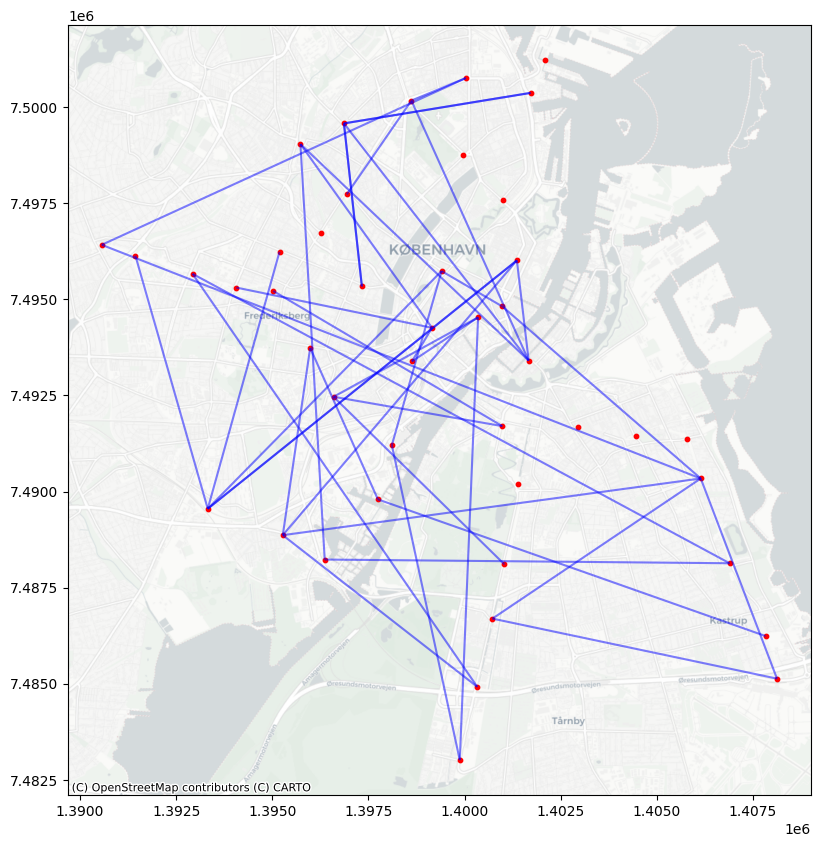

In [171]:
fig, ax = plt.subplots(1,1, figsize = (10,10))
od. plot(ax=ax, color="blue" , alpha=0.5)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

With this setup, I don't like that some nodes are isolated, and it makes no sense to connect nodes with the greatest distance.

Need to implement max distance of teh edge. 
Check along all nodes in that distance(k-neighbours) and then connected to them. 

In [194]:
def knn_edges_projected(gdf, id_col="stop_id", k=3, max_dist=None):
    """
    gdf: GeoDataFrame with Point geometry in a projected CRS (meters).
    max_dist: meters (optional). If set, drop neighbors farther than max_dist.
    Returns: DataFrame of edges (u, v, dist_m)
    """
    if gdf.crs is None:
        raise ValueError("gdf.crs is None. Set CRS before running kNN.")

    # If CRS is geographic (lat/lon), distances won't be meters → reproject
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())

    gdf = gdf_utm[[id_col, "geometry"]].dropna().reset_index(drop=True)
    
    print(gdf.head())
    
    # coordinates in meters
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    sindex = gdf.sindex
    edges = []

    for i, (u, x, y, geom) in enumerate(zip(gdf[id_col], xs, ys, gdf.geometry)):
        # Expand search window until we have enough candidates
        # (simple heuristic; works well for metro-scale datasets)
        r = 200.0  # start radius (m)
        cand_idx = []
        while len(cand_idx) < (k + 1):  # +1 includes itself
            bbox = (x - r, y - r, x + r, y + r)
            cand_idx = list(sindex.intersection(bbox))
            r *= 2
            if r > 50000:  # safety stop
                break

        # Compute distances to candidates
        dx = xs[cand_idx] - x
        dy = ys[cand_idx] - y
        d = np.hypot(dx, dy)

        # Sort by distance, skip itself
        order = np.argsort(d)
        picked = []
        for idx_in_list in order:
            j = cand_idx[idx_in_list]
            if j == i:
                continue
            dist_m = float(d[idx_in_list])
            if (max_dist is not None) and (dist_m > max_dist):
                continue
            picked.append((i, j, dist_m))
            if len(picked) >= k:
                break

        for _, j, dist_m in picked:
            v = gdf.loc[j, id_col]
            # undirected unique edge
            a, b = sorted((u, v))
            edges.append((a, b, dist_m))

    return pd.DataFrame(edges, columns=["u", "v", "dist_m"]).drop_duplicates()

edges_new = knn_edges_projected(gdf_stops_3857, id_col="stop_id", k=2, max_dist=1350)
print(edges_new.head())



   stop_id                        geometry
0  8603317  POINT (347310.264 6166387.238)
1  8603315  POINT (347605.405 6167453.405)
2  8603312    POINT (348066.915 6169235.6)
3  8603313  POINT (347863.034 6168446.486)
4  8603310  POINT (348105.355 6171264.121)
         u        v       dist_m
0  8603315  8603317  1106.264502
1  8603313  8603315  1025.954324
3  8603312  8603313   815.026663
4  8603311  8603312  1199.284699
7  8603310  8603311   879.704177


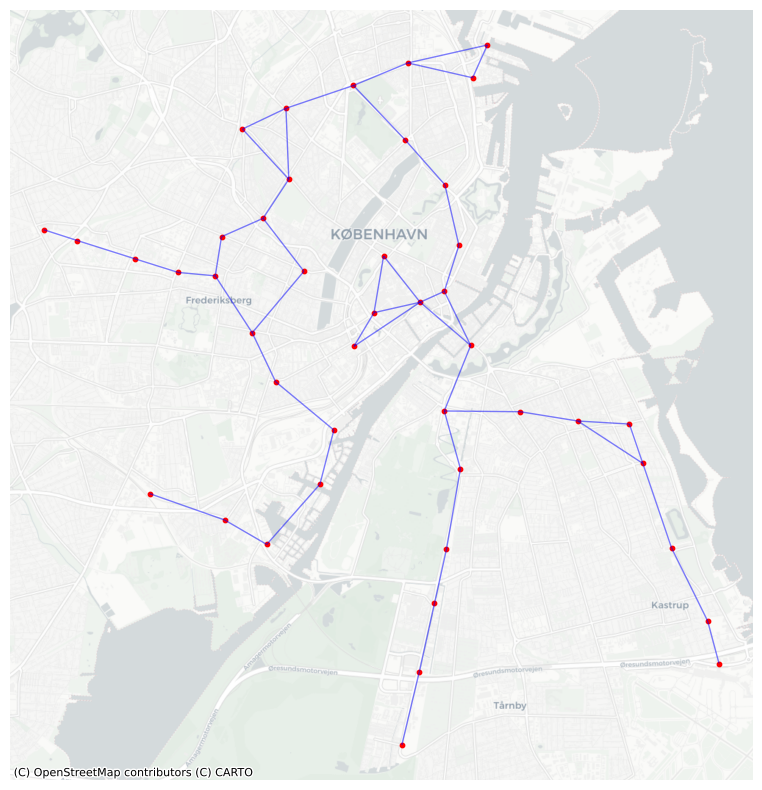

In [195]:
stops_plot = gdf_stops_3857.set_index("stop_id")

def make_line(row):
    p1 = stops_plot.loc[row["u"], "geometry"]
    p2 = stops_plot.loc[row["v"], "geometry"]
    return LineString([p1, p2])

edges_gdf_new = gpd.GeoDataFrame(
    edges_new.copy(),
    geometry=edges_new.apply(make_line, axis=1),
    crs=gdf_stops_3857.crs
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf_new.plot(ax=ax, color="blue", alpha=0.5, linewidth=1)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()

**Generate graph with NetworkX**


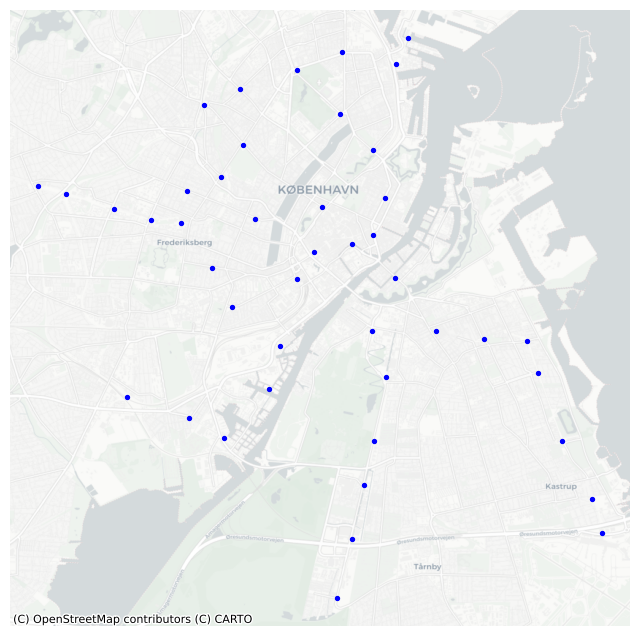

In [177]:
G = nx.Graph()
for name, row in gdf_stops_3857.iterrows():
    G.add_node(row["stop_name"], lat=row["stop_lat"], lon=row["stop_lon"])

pos = {name: (geom.x, geom.y) for name, geom in zip(gdf_stops_3857["stop_name"], gdf_stops_3857.geometry)}

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(G, pos,
        node_size=8,
        edge_color="gray",
        node_color="blue",
        ax=ax,
        with_labels=False)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

Parameters:

- max_routes = 4 , the amount of metro lines
- max_stops = 17 (red line), so the metro line is not longer than actual one
- max_distance , distance between stops 
- 

In [185]:
from itertools import combinations

dict_nodes = {}

gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)

dict_node = {
    row.stop_name: {"x": row.geometry.x, "y": row.geometry.y}
    for _, row in gdf.iterrows()
}

print(dict_node)

pair_dictionary = {}

for i, j in combinations(dict_node.keys(), 2):
    dx = dict_node[i]["x"] - dict_node[j]["x"]
    dy = dict_node[i]["y"] - dict_node[j]["y"]
    d = np.hypot(dx, dy)
    
    pair_dictionary.setdefault(i, {})[j] = d
    
print(len(pair_dictionary)) # 946 pairs
print(pair_dictionary)
    
for key in pair_dictionary.keys():
    nearest_station, min_dist = min(pair_dictionary[key].items(), key=lambda item: item[1])
    new_dict = {key: {"nearest_station": nearest_station, "distance": min_dist}}

print(new_dict)    
    

{'Vestamager St. (Metro)': {'x': 347310.2644256227, 'y': 6166387.2376485}, 'Ørestad St. (Metro)': {'x': 347605.4049686749, 'y': 6167453.405180991}, 'Sundby St. (Metro)': {'x': 348066.9153315721, 'y': 6169235.599994942}, 'Bella Center St. (Metro)': {'x': 347863.0344463676, 'y': 6168446.485906068}, 'Islands Brygge St. (Metro)': {'x': 348105.3552270056, 'y': 6171264.120920831}, 'DR Byen St. (Metro)': {'x': 348313.2024911691, 'y': 6170409.323311364}, 'Kongens Nytorv St. (Metro)': {'x': 348167.12071618123, 'y': 6173017.8150338335}, 'Christianshavn St. (Metro)': {'x': 348526.60938797775, 'y': 6172210.988172715}, 'Forum St. (Metro)': {'x': 346115.76055587607, 'y': 6173383.37661468}, 'Nørreport St. (Metro)': {'x': 347293.62735860783, 'y': 6173567.187381142}, 'Fasanvej St. (Metro)': {'x': 344271.5912137538, 'y': 6173431.940354218}, 'Frederiksberg St. (Metro)': {'x': 344811.47346465127, 'y': 6173363.00346383}, 'Flintholm St. (Metro)': {'x': 342806.5658250925, 'y': 6173952.286304374}, 'Lindevang 

In [184]:
pair_dictionary

{'Vestamager St. (Metro)': {'Ørestad St. (Metro)': np.float64(1106.2645015954154),
  'Sundby St. (Metro)': np.float64(2947.149241232909),
  'Bella Center St. (Metro)': np.float64(2132.14870075508),
  'Islands Brygge St. (Metro)': np.float64(4941.271074772933),
  'DR Byen St. (Metro)': np.float64(4145.24520900022),
  'Kongens Nytorv St. (Metro)': np.float64(6685.713063358611),
  'Christianshavn St. (Metro)': np.float64(5949.417218159673),
  'Forum St. (Metro)': np.float64(7097.379793200741),
  'Nørreport St. (Metro)': np.float64(7179.969007959598),
  'Fasanvej St. (Metro)': np.float64(7672.116468125027),
  'Frederiksberg St. (Metro)': np.float64(7409.808700429151),
  'Flintholm St. (Metro)': np.float64(8804.161643800067),
  'Lindevang St. (Metro)': np.float64(8145.294641425297),
  'Vanløse St. (Metro)': np.float64(9211.852473123145),
  'Lergravsparken St. (Metro)': np.float64(5413.774001049283),
  'Amagerbro St. (Metro)': np.float64(5191.154059732812),
  'Øresund St. (Metro)': np.float6